# Kigali Rental Price Estimation System - Model Notebook
**Author:** Caline Uwingabire  
**Supervisor:** Emmanuel Adjei  
**Track:** Machine Learning (Capstone Assignment 1)  

## Project Overview
Renting is a major housing reality in Kigali, Rwanda, affecting over 61% of private households. However, the market suffers from a lack of pricing transparency, leaving tenants, landlords, and agents to make pricing decisions with scattered and unstructured information. 

This notebook builds the data pipeline, performs Exploratory Data Analysis (EDA), engineering features, and compares regression models to establish the machine learning foundation of a **Rental Price Estimation System** that estimates fair rent ranges in Kigali based on property attributes.

### Notebook Contents:
1. **Environment Setup & Data Loading**
2. **Exploratory Data Analysis (EDA) & Data Visualization**
3. **Data Cleaning (Outlier Filtering)**
4. **Feature Engineering & Preprocessing**
5. **Model Training & Comparison**
6. **Model Evaluation & Metric Verification**
7. **Saving the Best Model for Web Integration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set design aesthetic for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
print("Libraries imported successfully.")

C:\Users\calin\AppData\Local\Temp\ipykernel_22956\3301211022.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries imported successfully.


## 1. Environment Setup & Data Loading
First, we load the Kigali Rental dataset containing 5,416 listings collected from public platforms and primary surveys.

In [2]:
csv_path = "Kigali_Rental_Final_Combined_With_Dataset1.csv"
df = pd.read_csv(csv_path)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Loaded dataset with 5416 rows and 14 columns.


,record_id,data_source,respondent_type,location,property_type,bedrooms,bathrooms,furnished_status,parking,security,road_access,amenities_count,monthly_rent_rwf,review_note
0,SURV-00081,Primary survey,Tenant,Biryogo,House,3,1,Unfurnished,Yes,No,Average,1,190000,NaN
1,SURV-00324,Primary survey,Landlord,Bumbogo,House,4,2,Unfurnished,No,No,Good,1,200000,NaN
2,SURV-00167,Primary survey,Real Estate Agent,Bumbogo,House,3,2,Unfurnished,Yes,No,Poor,2,490000,NaN
3,SURV-00278,Primary survey,Tenant,Bumbogo,Single Room,1,1,Unfurnished,No,No,Average,1,50000,NaN
4,SURV-00264,Primary survey,Other,Bumbogo,Single Room,1,1,Unknown,Unknown,Unknown,Poor,1,90000,NaN


## 2. Exploratory Data Analysis (EDA) & Data Visualization
Let's look at the distribution of the monthly rent target variable, inspect location-based averages, property types, and relationships between features.

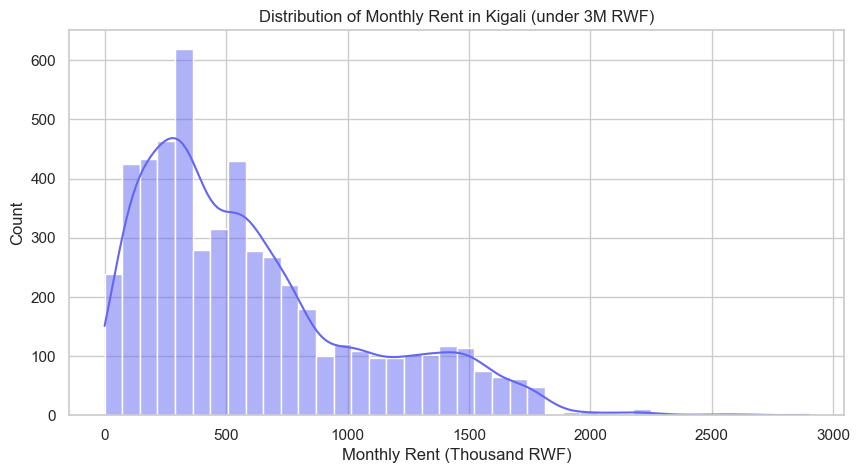

In [3]:
# Plot distribution of monthly rent (excluding extreme high outliers for plotting visualization)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['monthly_rent_rwf'] < 3000000]['monthly_rent_rwf'] / 1000, bins=40, kde=True, color='#6366f1')
plt.title('Distribution of Monthly Rent in Kigali (under 3M RWF)')
plt.xlabel('Monthly Rent (Thousand RWF)')
plt.ylabel('Count')
plt.savefig('rent_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\calin\AppData\Local\Temp\ipykernel_22956\1626076280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_avg.values, y=loc_avg.index, palette='crest')


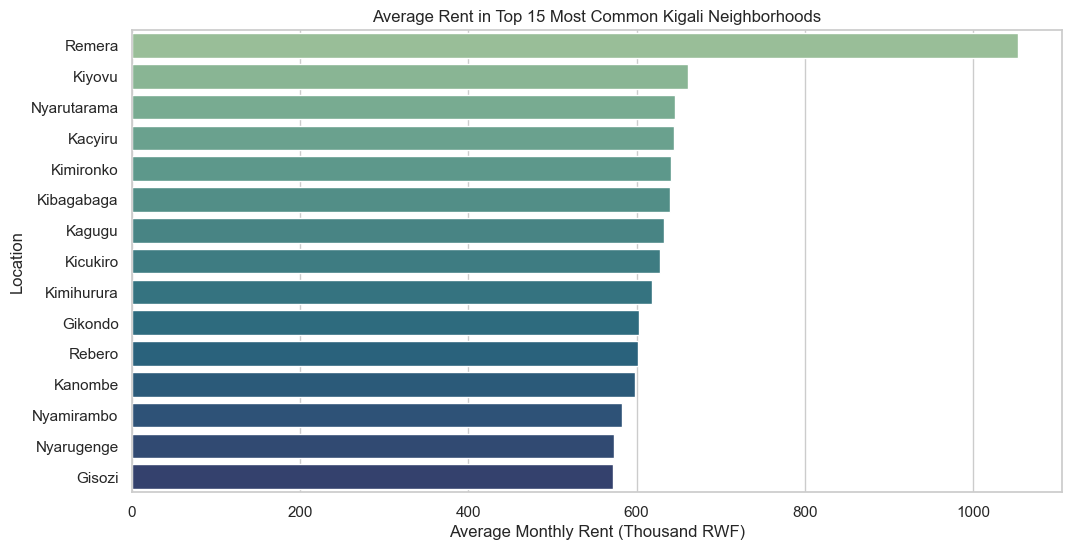

In [4]:
# Average Rent by Top 15 Locations
top_locations = df['location'].value_counts().head(15).index
df_top_loc = df[df['location'].isin(top_locations)]
loc_avg = df_top_loc.groupby('location')['monthly_rent_rwf'].mean().sort_values(ascending=False) / 1000

plt.figure(figsize=(12, 6))
sns.barplot(x=loc_avg.values, y=loc_avg.index, palette='crest')
plt.title('Average Rent in Top 15 Most Common Kigali Neighborhoods')
plt.xlabel('Average Monthly Rent (Thousand RWF)')
plt.ylabel('Location')
plt.savefig('location_average_rent.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\calin\AppData\Local\Temp\ipykernel_22956\2252255808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['monthly_rent_rwf'] < 2000000], x='property_type', y='monthly_rent_rwf', palette='Set2')


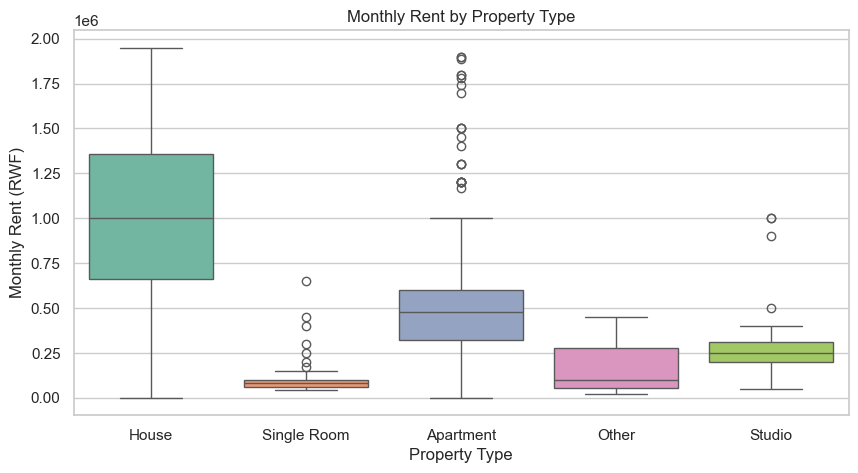

In [5]:
# Rent vs Property Type
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['monthly_rent_rwf'] < 2000000], x='property_type', y='monthly_rent_rwf', palette='Set2')
plt.title('Monthly Rent by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Monthly Rent (RWF)')
plt.savefig('rent_by_property_type.png', dpi=300, bbox_inches='tight')
plt.show()

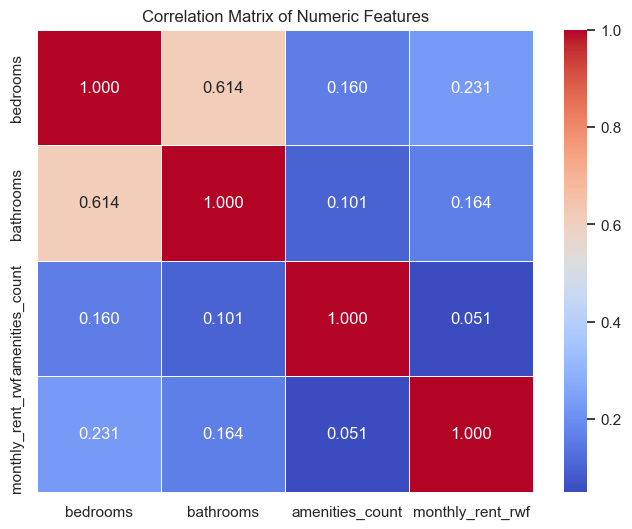

In [6]:
# Numeric correlation
numeric_cols = ['bedrooms', 'bathrooms', 'amenities_count', 'monthly_rent_rwf']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Data Cleaning (Outlier Filtering)
The dataset contains a `review_note` column that flags extreme outliers (e.g. rent amounts of 1 RWF or 150,000,000 RWF). We filter these out to ensure they do not bias our regression models.

In [7]:
# Display records with quality flags
flagged = df[df['review_note'].notnull()]
print("Flagged reviews to drop:")
print(flagged[['record_id', 'location', 'property_type', 'monthly_rent_rwf', 'review_note']])

# Cleaning the dataset
df_clean = df[df['review_note'].isnull()].copy()
print(f"Removed {len(flagged)} outlier records. Cleaned dataset has {df_clean.shape[0]} rows.")

Flagged reviews to drop:
       record_id        location property_type  monthly_rent_rwf  \
12    SURV-00034        Gacuriro     Apartment                 1   
16    SURV-05380        Gacuriro     Apartment          13000000   
306   SURV-00325         Gikondo         Other             22000   
4552  SURV-00259      Nyarutaran         House                 1   
4914  SURV-00192          Remera     Apartment                 2   
5046  SURV-05381          Remera     Apartment         150000000   
5289   PUB-05320  City Of Kigali         House          11280000   

                                       review_note  
12     Very low rent; review before model training  
16    Very high rent; review before model training  
306    Very low rent; review before model training  
4552   Very low rent; review before model training  
4914   Very low rent; review before model training  
5046  Very high rent; review before model training  
5289  Very high rent; review before model training  
Remove

## 4. Feature Engineering & Preprocessing
We construct a scikit-learn `ColumnTransformer` to automatically scale numerical columns using `StandardScaler` and encode categorical features using `OneHotEncoder`. We split the dataset into an 80% training set and a 20% test set.

In [8]:
# Define feature groups
numeric_features = ['bedrooms', 'bathrooms', 'amenities_count']
categorical_features = ['location', 'property_type', 'furnished_status', 'parking', 'security', 'road_access']

X = df_clean[numeric_features + categorical_features]
y = df_clean['monthly_rent_rwf']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construct the preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)
print("Preprocessor ColumnTransformer defined.")

Preprocessor ColumnTransformer defined.


## 5. Model Training & Comparison
We train four candidates: Linear Regression, Decision Tree, Random Forest, and Gradient Boosting Regressors. We evaluate each on the hold-out test set.

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15, min_samples_split=5),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=5)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE (RWF)': mae,
        'RMSE (RWF)': rmse,
        'R2 Score': r2
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,MAE (RWF),RMSE (RWF),R2 Score
0,Linear Regression,5.995690e+13,9.861041e+14,-3.957414e+18
1,Decision Tree,1.219325e+05,3.366679e+05,5.387150e-01
2,Random Forest,1.144770e+05,2.320673e+05,7.808236e-01
3,Gradient Boosting,1.130619e+05,2.418073e+05,7.620396e-01


## 6. Model Evaluation & Metric Verification
Let's visualize the results of the model comparison. Linear Regression has poor stability due to multicollinerity of location dummies, while ensemble models (Random Forest, Gradient Boosting) achieve robust scores.

C:\Users\calin\AppData\Local\Temp\ipykernel_22956\2159625265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Model', y='R2 Score', ax=axes[0], palette='viridis')
C:\Users\calin\AppData\Local\Temp\ipykernel_22956\2159625265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Model', y='MAE (RWF)', ax=axes[1], palette='rocket')


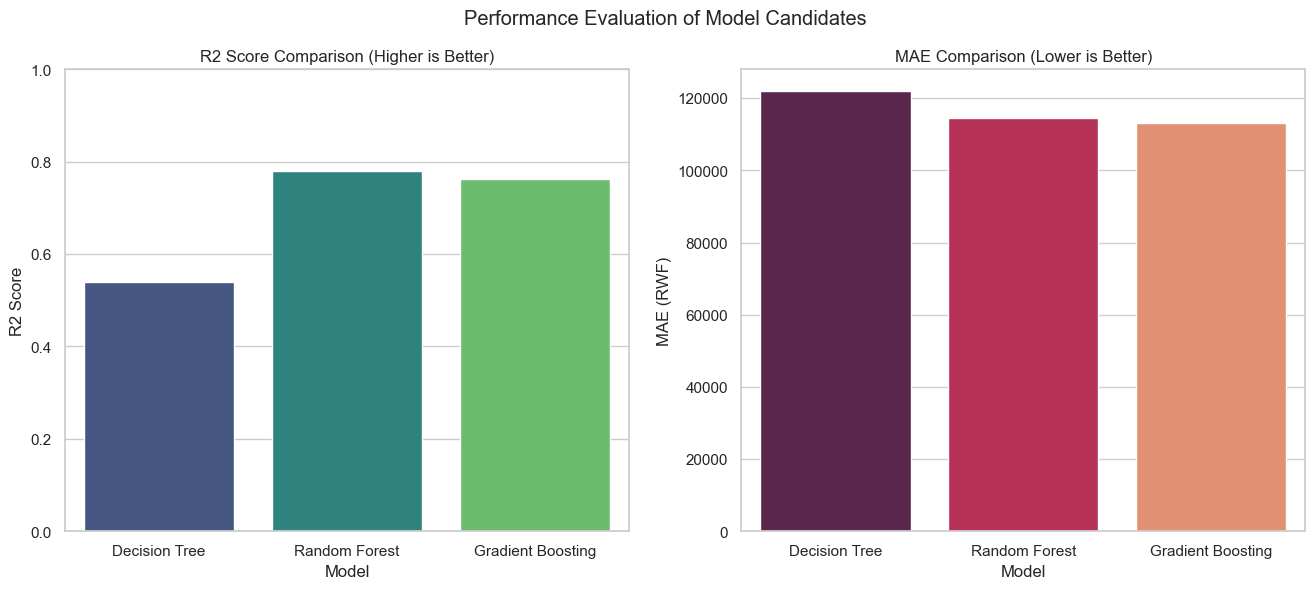

In [10]:
# Plot model comparisons (excluding Linear Regression due to scaling differences)
plot_df = results_df[results_df['Model'] != 'Linear Regression']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=plot_df, x='Model', y='R2 Score', ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score Comparison (Higher is Better)')
axes[0].set_ylim(0, 1.0)

sns.barplot(data=plot_df, x='Model', y='MAE (RWF)', ax=axes[1], palette='rocket')
axes[1].set_title('MAE Comparison (Lower is Better)')

plt.suptitle('Performance Evaluation of Model Candidates')
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\calin\AppData\Local\Temp\ipykernel_22956\3384106473.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='mako')


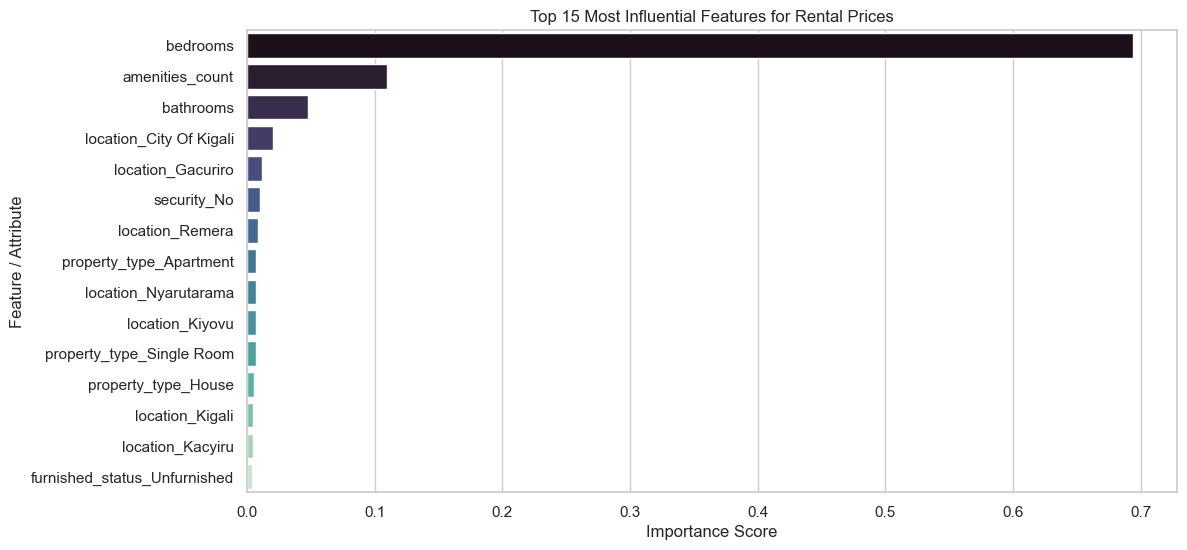

In [11]:
# Extract Feature Importance from the Random Forest Model
rf_model = trained_pipelines['Random Forest'].named_steps['regressor']
cat_encoder = trained_pipelines['Random Forest'].named_steps['preprocessor'].named_transformers_['cat']

# Get feature names
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_features)

# Importance dataframe
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Most Influential Features for Rental Prices')
plt.xlabel('Importance Score')
plt.ylabel('Feature / Attribute')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Saving the Best Model for Web Integration
We fit the best model (Random Forest) on the complete cleaned dataset to maximize sample learning and save it as a serialized pipeline `best_model.joblib` to load in our web application.

In [12]:
best_pipeline = trained_pipelines['Random Forest']
best_pipeline.fit(X, y)

joblib.dump(best_pipeline, 'best_model.joblib')
print("Best model pipeline successfully trained on all data and saved to best_model.joblib!")

Best model pipeline successfully trained on all data and saved to best_model.joblib!
